# Test optimiser for N = 2 ^ 16

see what graph it gives for 5 * P(v) and alpha = 0.95

## Imports

In [115]:
from hashlib import sha256
import time
from tqdm import tqdm
import mmh3
from math import e, log, pi, sqrt
from statistics import NormalDist
from scipy.optimize import minimize, Bounds
import pickle
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
from time import perf_counter

In [144]:
def m_t(inputs, N, m_0):  ## the m_t function as a target function
    ### the input variables to find are as follows:
    # input[0] is the number of starting points
    # input[1:] is the K_j for all 1<=j<=t

    K_js = inputs[1:]  # K_j values
    m = m_0  # starting m value

    # this is doing some sort of stats to find the expected m_i+1 value for the column 
    for k in K_js:  # iterate through the column
        # Calculate E1 and E2
        E1 = (1 - 1 / N) ** m
        E2 = (1 - 2 / N) ** m
        # calculate the statistical average of m_j+1
        average = N * (1 - E1)
        # check if the variance is positive, sometimes error happens because of float calculation on very small values
        if N * ((N - 1) * E2 + E1 - N * E1 ** 2) < 0:   # this equation gives the variance, so sqrt to get standard deviation
            # if it is negative (error), set it to 0
            sd = 0
        else:
            # count the statistical variance of m_j+1 otherwise
            sd = sqrt(N * ((N - 1) * E2 + E1 - N * E1 ** 2))
        # find the m_j+1
        m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd

    # return -m to maximise the amount of points with optimiser
    return -m

## define the objective and target functions
def cost(inputs, N, m_0):  ## the cost calculation function as objective function to be minimized
    ### the input variables to find are as follows:
    # input[0] is the number of starting points
    # input[1:] is the K_j for all 1<=j<=t
    K_js = inputs[1:]  # K_j values
    cost = 0  # cost counter
    m_values = [m_0]  # list to keep the mj values

    for k in K_js:  # iterate through the column
        # Calculate E1 and E2
        E1 = (1 - 1 / N) ** m_0
        E2 = (1 - 2 / N) ** m_0
        # calculate the statistical average of m_j+1
        average = N * (1 - E1)
        ## check if the variance is positive, sometimes error happens because of float calculation on very small values
        if N * ((N - 1) * E2 + E1 - N * E1 ** 2) < 0:
            # if it is negative (error), set it to 0
            variance = 0
        else:
            # count the variance otherwise
            variance = sqrt(N * ((N - 1) * E2 + E1 - N * E1 ** 2))
        # count the cost before defining the new m
        cost += m_0 + m_0 * k / 577.44
        # find the m_j+1
        m_0 = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * variance
        m_values.append(m_0)
        # count the cost

    # return cost - not square rooted as we are bounding cost
    return cost, m_values

def vanilla_cost(N, m_0, t):
    # keep track of cost
    cost = 0
    # set m to be the starting m_0
    m = m_0
    # append m to the list of m_values to be returned
    m_values = [m]

    # iterate through each column
    for i in range(t):
        # calculate cost - add 1 for each hash we do (m hashes in this column)
        cost = cost + m

        # use formula m_i+1 = N(1 - (1 - 1/N)^m_i)
        m = N * (1 - ((1 - (1 / N)) ** m))
        m_values.append(m)

    return cost, m_values

###############################################################################################################################

# Optimise 
# add vcost to bound the optimisation
def optimise_kj(N, p, alpha, factor, lower_bound, t=-1):   # add v_cost if want vanilla cost to be set beforehand

    if t == -1:
        t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t
    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    if alpha == 1:
        m_0 = N
    else:
        m_0 = round(mt_target/(1-alpha))    # our starting m_0

    
    ## set the bound and target function
    bound = Bounds([lower_bound for i in range(t)], [float('inf') for i in range(t)])
    
    # our target function that needs to be > 0
    # instead of using the target function, we can use the cost function as the objective function
    # need to get the cost of a vanilla rainbow table with the same parameters
    
    # Const * P(vanilla) - P(cherry) > 0
    v_cost, m = vanilla_cost(N, m_0, t)
    v_cost = v_cost * factor
    ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - cost(x, N, m_0)[0]}

    ## use 1 as starting values for cherry-picking
    starting_values = [1 for i in range(t)]
    

    print("edited")
    ## call the optimizer
    # maximise the 
    # 5000000 normally
    res = minimize(lambda Kj: m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "SLSQP", options={'disp': True, "maxiter": 5000000, "eps": 1, "ftol": 1})
    # res = minimize(lambda Kj: m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "L-BFGS-B", options={'disp': True, "maxiter": 5000000, "eps": 1, "ftol": 1})
    
    ## res.x is the result of the optimization
    final_cost, m_values = cost(res.x, N, m_0) # calculate the final cost and m values
    return res.x, m_0, final_cost, m_values

## Get data for N = 2^16

In [213]:
N = 2 ** 21
p = 1 - e ** (-2)
alpha = 0.95

In [214]:
# result = [kjs, m_0, final_cost, m_values]
start_time = perf_counter()
result = optimise_kj(N, p, alpha, 5, 1, t=1000)
end_time = perf_counter()
old_time = end_time - start_time
kjs, m_0, final_cost, m_values = result

edited
Optimization terminated successfully    (Exit mode 0)
            Current function value: -8200.808134189247
            Iterations: 15
            Function evaluations: 15025
            Gradient evaluations: 15


In [172]:
m_values[-1]

19490.048659328517

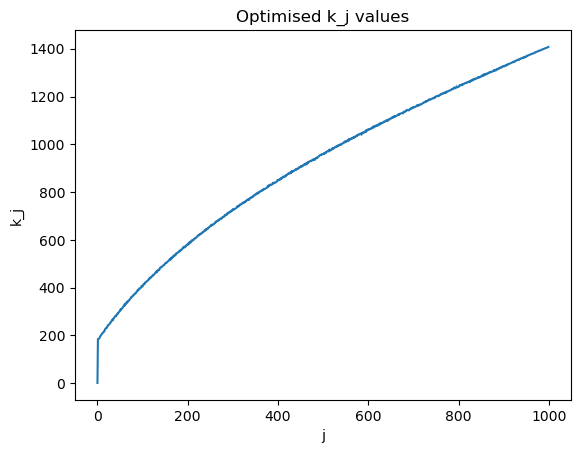

In [215]:
## plot kjs with k_j value as y axis and j value as x axis as line plot
plt.plot(kjs)
plt.xlabel('j')
plt.ylabel('k_j')
plt.title('Optimised k_j values')
plt.show()

## Adapt optimise


### What is the cost of the reduction function?

In [53]:
%%script false

def H_c(x):
    return sha256(x.to_bytes(8, 'little')).digest()  # return bytes directly

def r_c(N, t, y, i, ell=0):
    seed = int(i) + (ell*t)
    return mmh3.hash(y, seed, signed=False) % N

Couldn't find program: 'false'


In [54]:
%%script false
import pandas as pd
from time import perf_counter
data = pd.DataFrame([[0]*1]*10000, columns=["murmurhash"])
time = pd.DataFrame([[0]*2]*10000, columns=["hash", "reduction"])

initial_hash_table = []
hash_times = []
for i in range(2000000):
    #start = perf_counter()
    initial_hash_table.append(H_c(i))
    #end = perf_counter()
    #hash_times.append(end - start)

# add hash_times as hash column in time dataframe
# time["hash"] = hash_times

red_times = []
red_count = 0
### murmurhash reduction function
for index in range (10000):
    table = {}
    for i in range (10000):
        #start = perf_counter()
        value = r_c(N, 80, initial_hash_table[i], index)
        #end = perf_counter()
        #red_times.append(end - start)
        # table[r_c(N, 80, initial_hash_table[i], index)] = i
        # red_count += 1
        table[value] = i
    data["murmurhash"][index] = len(table)

# time["reduction"] = red_times


Couldn't find program: 'false'


In [55]:
%%script false
# time the hashes
initial_hash_table = []
start = perf_counter()
for i in range(2000000):
    # initial_hash_table.append(H_c(i))
    H_c(i)
end = perf_counter()
hash_time = (end - start) / 2000000

for i in range(2000000):
    initial_hash_table.append(H_c(i))


red_times = []
iterations = 2000000


start = perf_counter()

for i in range(iterations):
    # Only the core operation
    r_c(N, 80, initial_hash_table[i], index)
    
end = perf_counter()

# Calculate average: (Total Time) / (Number of runs)
red_time = (end - start) / iterations

Couldn't find program: 'false'


In [56]:
%%script false
# Calculate the ratio factor
ratio_factor = red_time / hash_time

print(f"The ratio of Hash Time to Reduction Time is 1 : {ratio_factor:.4f}")

Couldn't find program: 'false'


In [57]:
%%script false
ratio_factor = hash_time / red_time

print(f"The ratio of Hash Time to Reduction Time is 1 : {ratio_factor:.4f}")
# The ratio of Hash Time to Reduction Time is 1 : 2.3633

Couldn't find program: 'false'


In [58]:
%%script false
data.describe()

Couldn't find program: 'false'


### numpy arrays

In [ ]:
def adapt_m_t(inputs, N, m_0):  # target function: maximize m_t via minimizing -m_t
    K_js = np.asarray(inputs[1:], dtype=float)
    m = float(m_0)
    nd = NormalDist()

    for k in K_js:
        E1 = (1 - 1 / N) ** m
        E2 = (1 - 2 / N) ** m
        average = N * (1 - E1)

        var_term = N * ((N - 1) * E2 + E1 - N * E1**2)
        sd = sqrt(var_term) if var_term > 0 else 0.0

        p = (k - pi / 8) / (k - pi / 4 + 1)
        p = np.clip(p, 1e-12, 1 - 1e-12)  # numerical safety for inv_cdf
        m = average + nd.inv_cdf(p) * sd

    return -m

def adapt_cost(inputs, N, m_0):  # cost calculation function as objective function to be minimized
    K_js = np.asarray(inputs[1:], dtype=float)
    cost = 0.0
    m_values = np.empty(len(K_js) + 1, dtype=float)
    m_values[0] = m_0

    for idx, k in enumerate(K_js, start=1):
        E1 = (1 - 1 / N) ** m_0
        E2 = (1 - 2 / N) ** m_0
        average = N * (1 - E1)

        var_term = N * ((N - 1) * E2 + E1 - N * E1 ** 2)
        variance = 0.0 if var_term < 0 else sqrt(var_term)

        cost += m_0 + m_0 * k / 577.44
        m_0 = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * variance
        m_values[idx] = m_0

    return cost, m_values

def adapt_vanilla_cost(N, m_0, t):
    cost = 0.0
    m_values = np.empty(t + 1, dtype=float)
    m_values[0] = m_0

    m = m_0
    for i in range(t):
        cost += m
        m = N * (1 - ((1 - (1 / N)) ** m))
        m_values[i + 1] = m

    return cost, m_values

###############################################################################################################################

# Optimise 
# add vcost to bound the optimisation
def adapt_optimise_kj(N, p, alpha, factor, lower_bound, t=-1):   # add v_cost if want vanilla cost to be set beforehand
    if t == -1:
        t = round(log(1 - p) / log(1 - N ** (-1 / 3)))  # Calculate t

    mt_max = (2 * N) / (t + 2)
    mt_target = alpha * mt_max
    if alpha == 1:
        m_0 = N
    else:
        m_0 = round(mt_target / (1 - alpha))  # starting m_0

    # bounds as numpy arrays
    bound = Bounds(
        np.full(t, lower_bound, dtype=float),
        np.full(t, np.inf, dtype=float)
    )

    # vanilla cost baseline
    v_cost, _ = adapt_vanilla_cost(N, m_0, t)
    v_cost *= factor

    ineq_cons = {
        'type': 'ineq',
        'fun': lambda x: v_cost - adapt_cost(x, N, m_0)[0]
    }

    starting_values = np.ones(t, dtype=float)

    res = minimize(
        lambda Kj: m_t(Kj, N, m_0),
        starting_values,
        bounds=bound,
        constraints=ineq_cons,
        method="SLSQP",
        options={'disp': True, "maxiter": 5000000, "eps": 1, "ftol": 1}
    )

    final_cost, m_values = adapt_cost(res.x, N, m_0)
    return res.x, m_0, final_cost, m_values


In [ ]:
%%script false

# result = [kjs, m_0, final_cost, m_values]
start_time = perf_counter()
a_result = adapt_optimise_kj(N, p, alpha, 5, 1)
end_time = perf_counter()
adapt_time = end_time - start_time
a_kjs, a_m_0, a_final_cost, a_m_values = a_result

Optimization terminated successfully    (Exit mode 0)
            Current function value: -2264.0897222533777
            Iterations: 19
            Function evaluations: 1550
            Gradient evaluations: 19


In [ ]:
%%script false

if adapt_time < old_time:
    print(f"Adapted optimisation is faster by a factor of {old_time / adapt_time:.2f}")
else:
    print(f"Original optimisation is faster by a factor of {adapt_time / old_time:.2f}")

Adapted optimisation is faster by a factor of 1.01


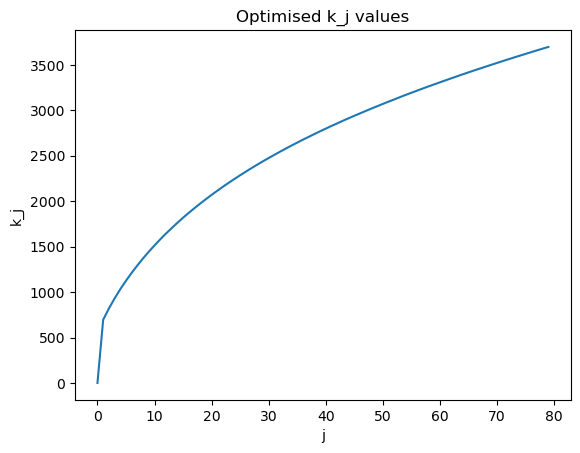

In [ ]:
%%script false
## plot kjs with k_j value as y axis and j value as x axis as line plot
plt.plot(a_kjs)
plt.xlabel('j')
plt.ylabel('k_j')
plt.title('Optimised k_j values')
plt.show()

### can we parallelise?